In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import matplotlib.pyplot as plt

import anndata as ad

from graph_transformer_long_range_niches.pp import sliding_window, compute_neighborhood_stats
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, COSMX_PANCREAS_S1, COSMX_PANCREAS

import warnings
warnings.filterwarnings('ignore')

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Imp

# Pig Xenium data

In [10]:
adata = sc.read_h5ad("/lustre/groups/ml01/datasets/projects/2024_Lickert_pig_pancreas_sara.jimenez/e60_cell_charter.h5ad")
adata

AnnData object with n_obs × n_vars = 943258 × 479
    obs: 'transcripts', 'unique_transcripts', 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'cell_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'sample', '_scvi_batch', '_scvi_labels', 'cell_type_coarse', 'cell_type', 'cluster_cellcharter', 'niche_label', 'globalX', 'globalY', 'sliding_window_assignment'
    var: 'feature_types', 'genome', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_counts-1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type', 'cell_type_coarse_colors', 'cell_type_colors', 'cluster_cellcharter_cell_typ

First we inspect the count distribution. Ideally, the counts should be normalized between 0 to 3. 

In [3]:
adata.obs['sample']

lhhijpoa-1-0     sample9
gdgkphle-1-0     sample9
chggfmid-1-0     sample9
dfopdadn-1-0     sample9
ahnlline-1-0     sample9
                  ...   
ncnokffk-1-1    sample10
fafiilhf-1-1    sample10
bechljef-1-1    sample10
bfhokopg-1-1    sample10
nobnbpfn-1-1    sample10
Name: sample, Length: 943258, dtype: category
Categories (2, object): ['sample9', 'sample10']

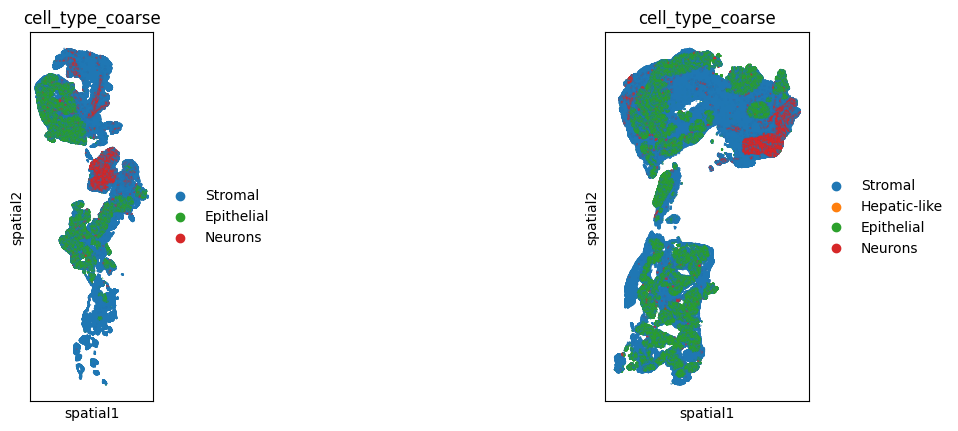

In [4]:
sq.pl.spatial_scatter(adata,
                      library_key = 'sample', 
                      #library_id = ['sample9', 'sample10'],
                      color = 'cell_type_coarse',
                      shape= None,)

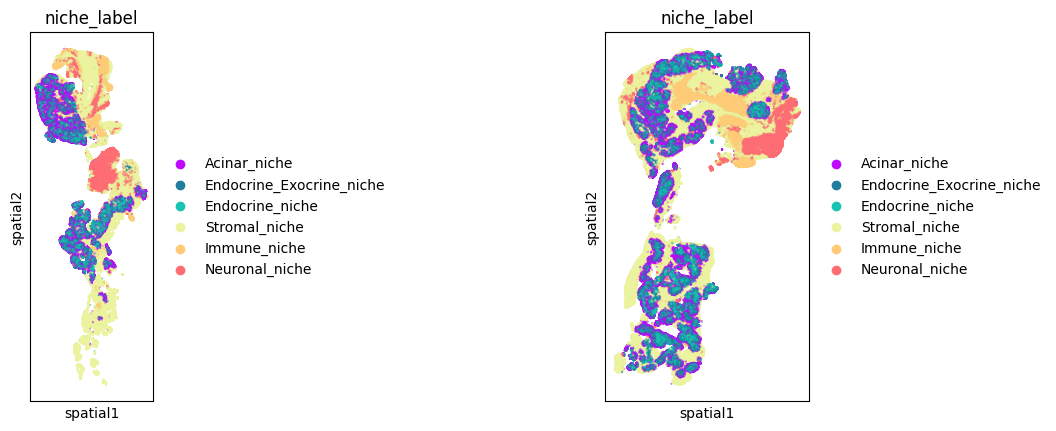

In [5]:
sq.pl.spatial_scatter(adata,
                      library_key = 'sample', 
                      #library_id = ['sample9', 'sample10'],
                      color = 'niche_label',
                      shape= None,)

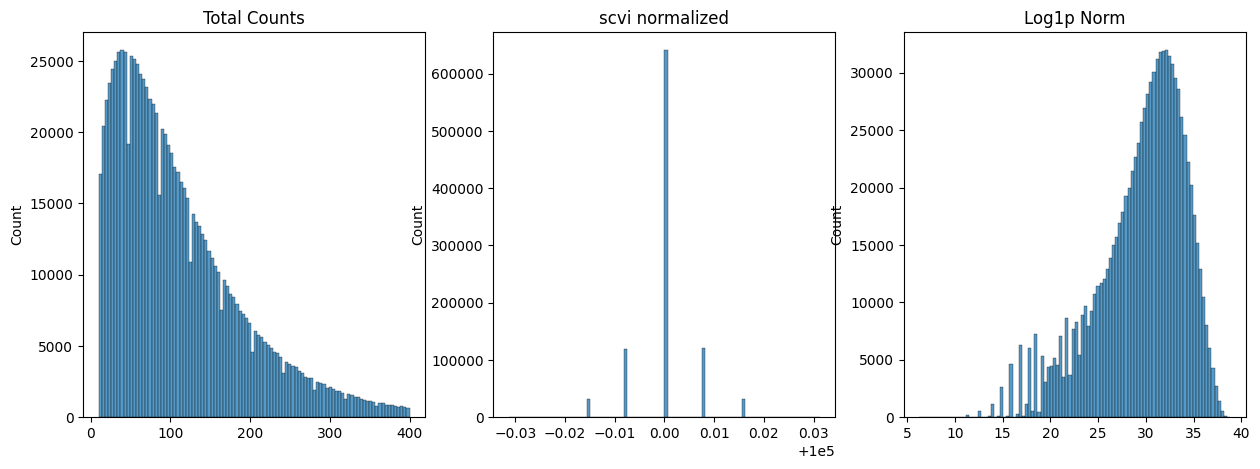

In [8]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p0 = sns.histplot(adata.layers["counts"].sum(1), bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total Counts")
p1 = sns.histplot(adata.layers["scvi_normalized"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("scvi normalized")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[2])
axes[2].set_title("Log1p Norm")
plt.show()

In [16]:
print('scvi norm - min: ', adata.layers["scvi_normalized"].min(), ', max: ', adata.layers["scvi_normalized"].max())
print('Log1p norm - min: ', adata.layers["log1p_norm"].min(), ', max: ', adata.layers["log1p_norm"].max())

scvi norm - min:  3.9751005e-17 , max:  57278.246
Log1p norm - min:  0.0 , max:  3.310467


In [7]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["raw"] = adata.X
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

## Sliding window

In [19]:
MAX_NR_CELLS = 2000

In [20]:
sq.tl.sliding_window(
    adata=adata,
    library_key="sample",  # to stratify by sample
    window_size=300,
    overlap=0,
    copy=False,  # we modify in place
)

In [21]:
del adata.uns['sliding_window_assignment_colors']

Statistics for sliding_window_assignment:
count    1279.000000
mean      737.496482
std       557.005162
min         1.000000
25%       244.000000
50%       615.000000
75%      1227.500000
max      2288.000000
dtype: float64


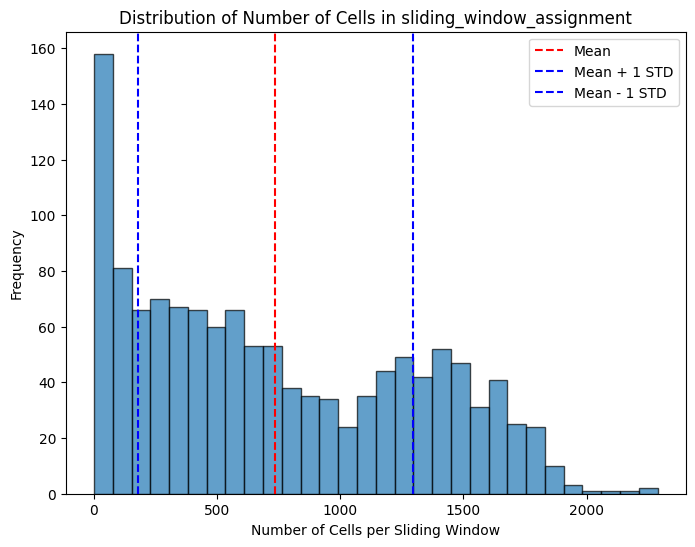

In [23]:
total_window_counts = 0

# Iterate through each sliding window ID column
for sliding_window_id in adata.obs.columns[adata.obs.columns.str.contains("sliding_window")]:
    # Calculate the size (number of cells) for each sliding window
    window_sizes = adata.obs.groupby(sliding_window_id).size()
    
    # Display the window sizes
    print(f"Statistics for {sliding_window_id}:")
    print(window_sizes.describe())  # Get a summary of the statistics (min, max, mean, etc.)
    
    # Calculate and print additional statistics
    max_cells = window_sizes.max()
    min_cells = window_sizes.min()
    mean_cells = window_sizes.mean()
    std_cells = window_sizes.std()

    # if mean_cells > 2000:
    #     print(f'Delete {sliding_window_id}')
    #     del adata.obs[sliding_window_id]
    # else:
    #     total_window_counts += len(window_sizes)
        
    # Plot the distribution of the number of cells
    plt.figure(figsize=(8, 6))
    plt.hist(window_sizes, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(mean_cells, color='red', linestyle='--', label='Mean')
    plt.axvline(mean_cells + std_cells, color='blue', linestyle='--', label='Mean + 1 STD')
    plt.axvline(mean_cells - std_cells, color='blue', linestyle='--', label='Mean - 1 STD')
    plt.xlabel('Number of Cells per Sliding Window')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Number of Cells in {sliding_window_id}')
    plt.legend()
    plt.show()

In [16]:
# color all sliding windows with <=100
sw_counts = adata.obs['sliding_window_assignment'].value_counts()

adata.obs['sw_low_nr_cells_100'] = adata.obs['sliding_window_assignment'].map(sw_counts) < 100
adata.obs['sw_low_nr_cells_300'] = adata.obs['sliding_window_assignment'].map(sw_counts) < 300

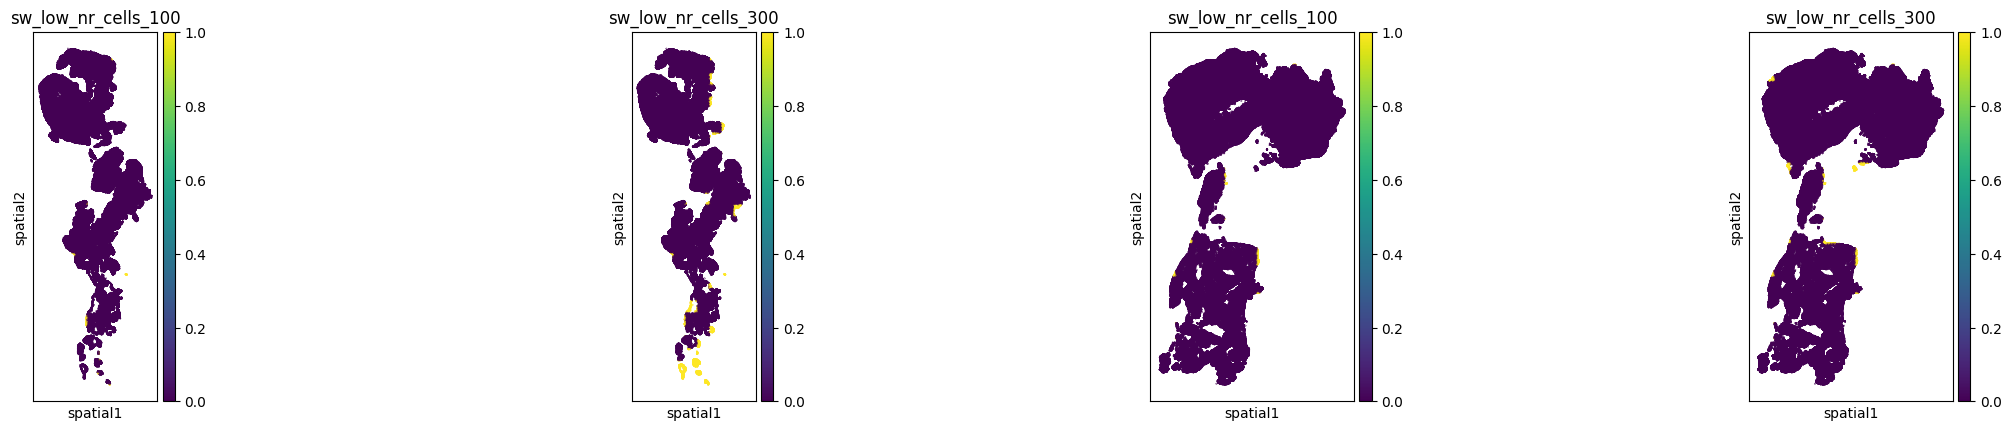

In [17]:
sq.pl.spatial_scatter(
            adata,
            color = ['sw_low_nr_cells_100', 'sw_low_nr_cells_300'],
            library_key = 'sample',
            spatial_key = 'spatial',
            shape= None,
)

In [18]:
print(adata.obs['sw_low_nr_cells_300'].sum())

4836


In [19]:
adata.write('/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/xenium_pig_pancreas.h5ad')

### Exclude sliding windows with low number of cells

In [24]:
adata = adata[~ adata.obs['sw_low_nr_cells_300']]
adata

View of AnnData object with n_obs × n_vars = 938422 × 479
    obs: 'transcripts', 'unique_transcripts', 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'cell_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'sample', '_scvi_batch', '_scvi_labels', 'cell_type_coarse', 'cell_type', 'cluster_cellcharter', 'niche_label', 'globalX', 'globalY', 'sliding_window_assignment', 'sw_low_nr_cells', 'sw_low_nr_cells_100', 'sw_low_nr_cells_300'
    var: 'feature_types', 'genome', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_counts-1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type', 'ce

In [25]:
adata.write('/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/xenium_pig_pancreas_pp.h5ad')

## Split data

In [35]:
from sklearn.model_selection import train_test_split

adata.obs['split'] = None

## sample 10 for training
adata.obs.loc[adata.obs['sample'] == 'sample10', 'split'] = 'train'

# Other sample randomly split into val and test (50/50)
other_samples_mask = adata.obs['sample'] != 'sample10'
unique_windows = adata.obs.loc[other_samples_mask, 'sliding_window_assignment'].unique()

val_windows, test_windows = train_test_split(
    unique_windows, 
    test_size=0.5, 
    random_state=42  
)
adata.obs.loc[adata.obs['sliding_window_assignment'].isin(val_windows), 'split'] = 'val'
adata.obs.loc[adata.obs['sliding_window_assignment'].isin(test_windows), 'split'] = 'test'

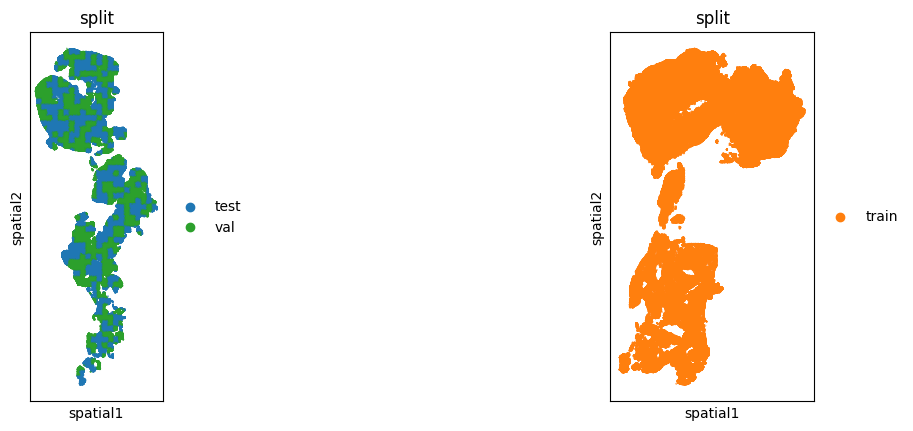

In [38]:
sq.pl.spatial_scatter(adata,
                      library_key = 'sample', 
                      color = 'split',
                      shape= None,)

In [39]:
adata.write('/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/xenium_pig_pancreas_pp.h5ad')

## Neighborhood connectivity

In [2]:
adata = sc.read_h5ad('/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/xenium_pig_pancreas_pp.h5ad')

In [9]:
sq.gr.spatial_neighbors(
    adata,
    radius=30,
    coord_type="generic",
    library_key = "sample"
)

In [10]:
conn = adata.obsp['spatial_connectivities']

In [11]:
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

Average number of connections per node: 45.11
